IT25101492 — Individual Model Implementation
Laksith R — Progress Review II (Final Evaluation — Implementation)

Model family: Classification — Decision Tree

1. Model suitability to the assigned dataset and chosen problem
A Decision Tree naturally handles the mix of continuous clinical measurements (HbA1c, glucose,
BMI, blood pressure) and binary lifestyle flags (family history, hypertension history) in this
dataset without needing feature scaling assumptions, and — unlike Logistic Regression — it can
capture non-linear, threshold-based clinical rules (e.g. "if HbA1c > x AND glucose_fasting > y
then Type 2"), which mirrors how clinicians actually reason about diabetes staging. It is also
directly interpretable via its rule structure, which is valuable for a clinical-facing model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
pd.set_option('display.max_columns', 30)

target_col = 'diabetes_stage_encoded'
labels_map = {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Gestational', 3: 'Type 2'}

In [3]:
train_full = pd.read_csv('../../../for progress/results/outputs/stage6_train_balanced.csv')
test_df   = pd.read_csv('../../../for progress/results/outputs/stage6_test_holdout.csv')

In [4]:
SAMPLE_PER_CLASS = 4000
parts = []
for cls, g in train_full.groupby(target_col):
    parts.append(g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=42))
train_df = pd.concat(parts, ignore_index=True)

In [5]:
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test  = test_df.drop(columns=[target_col])
y_test  = test_df[target_col]

In [6]:
print('Train (sampled):', X_train.shape, dict(y_train.value_counts().sort_index()))
print('Test  (untouched, imbalanced):', X_test.shape, dict(y_test.value_counts().sort_index()))

Train (sampled): (16000, 20) {0: np.int64(4000), 1: np.int64(4000), 2: np.int64(4000), 3: np.int64(4000)}
Test  (untouched, imbalanced): (19436, 20) {0: np.int64(1547), 1: np.int64(6203), 2: np.int64(53), 3: np.int64(11633)}


 2. Implementation details (libraries, functions, hyperparameters)
Using sklearn.tree.DecisionTreeClassifier. Key hyperparameters explored: max_depth, min_samples_leaf, and criterion (gini vs entropy).

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

In [8]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, results):
    y_pred = model.predict(X_te)
    report = classification_report(y_te, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)],
                                    output_dict=True, zero_division=0)
    acc = report['accuracy']
    f1w = report['weighted avg']['f1-score']
    results.append({'variant': name, 'accuracy': acc, 'weighted_f1': f1w})
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)], zero_division=0))
    return y_pred

In [9]:
def plot_confusion(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred, labels=sorted(labels_map))
    disp = ConfusionMatrixDisplay(cm, display_labels=[labels_map[c] for c in sorted(labels_map)])
    fig, ax = plt.subplots(figsize=(5.5, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

results = []

In [10]:
# Variant A: baseline, unconstrained depth (likely to overfit)
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
evaluate('DecisionTree - baseline (unlimited depth)', dt_base, X_train, y_train, X_test, y_test, results)
print('Tree depth reached:', dt_base.get_depth(), '| leaves:', dt_base.get_n_leaves())

--- DecisionTree - baseline (unlimited depth) ---
              precision    recall  f1-score   support

 No Diabetes       0.84      0.90      0.87      1547
Pre-Diabetes       0.82      0.84      0.83      6203
 Gestational       0.01      0.11      0.01        53
      Type 2       0.93      0.82      0.87     11633

    accuracy                           0.83     19436
   macro avg       0.65      0.67      0.65     19436
weighted avg       0.88      0.83      0.86     19436

Tree depth reached: 40 | leaves: 1206


3. Parameter tuning method — GridSearchCV
Search over max_depth, min_samples_leaf, criterion with 5-fold CV, scoring = weighted F1.

Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1} CV weighted-F1: 0.8842
--- DecisionTree - GridSearchCV {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1} ---
              precision    recall  f1-score   support

 No Diabetes       0.85      0.91      0.88      1547
Pre-Diabetes       0.82      0.88      0.85      6203
 Gestational       0.01      0.13      0.01        53
      Type 2       0.94      0.82      0.87     11633

    accuracy                           0.84     19436
   macro avg       0.65      0.69      0.65     19436
weighted avg       0.89      0.84      0.86     19436



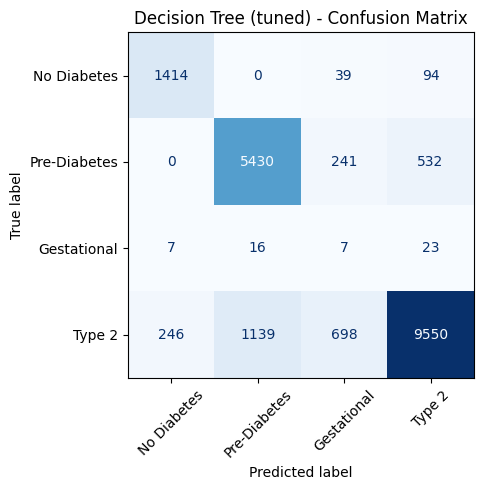

In [4]:
param_grid = {
    'max_depth': [4, 6, 8, 12, None],
    'min_samples_leaf': [1, 5, 20],
    'criterion': ['gini', 'entropy'],
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
                     scoring='f1_weighted', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_, 'CV weighted-F1:', round(grid.best_score_, 4))
dt_tuned = grid.best_estimator_
y_pred_tuned = evaluate(f"DecisionTree - GridSearchCV {grid.best_params_}", dt_tuned, X_train, y_train, X_test, y_test, results)
plot_confusion(y_test, y_pred_tuned, 'Decision Tree (tuned) - Confusion Matrix')


--- DecisionTree - shallow interpretable (max_depth=4) ---
              precision    recall  f1-score   support

 No Diabetes       0.85      0.97      0.91      1547
Pre-Diabetes       0.81      0.68      0.74      6203
 Gestational       0.01      0.62      0.01        53
      Type 2       1.00      0.64      0.78     11633

    accuracy                           0.68     19436
   macro avg       0.67      0.73      0.61     19436
weighted avg       0.93      0.68      0.78     19436



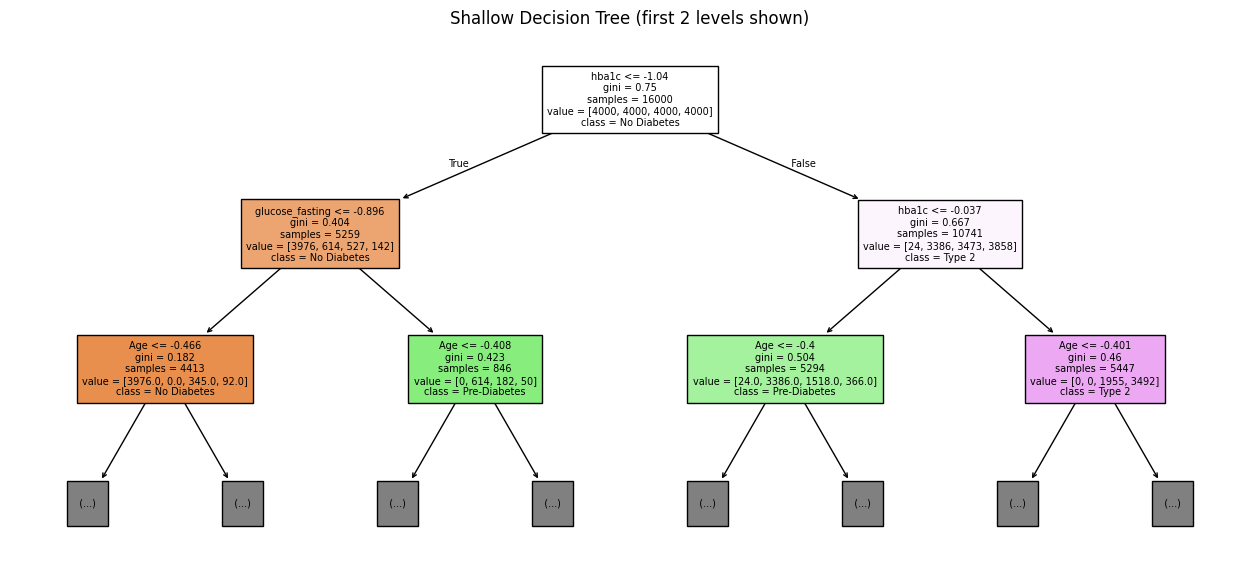

In [5]:
# Variant C: shallow, highly-constrained tree for interpretability comparison
dt_shallow = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)
dt_shallow.fit(X_train, y_train)
evaluate('DecisionTree - shallow interpretable (max_depth=4)', dt_shallow, X_train, y_train, X_test, y_test, results)

plt.figure(figsize=(16, 7))
plot_tree(dt_shallow, feature_names=X_train.columns, class_names=[labels_map[c] for c in sorted(labels_map)],
          filled=True, fontsize=7, max_depth=2)
plt.title('Shallow Decision Tree (first 2 levels shown)')
plt.show()


4. Evaluation metric(s), validation method, comparison, conclusion, limitations
Metrics: accuracy and weighted F1 (weighted F1 primary, for the same imbalance reasons as Member 1). Validation: 5-fold CV during grid search, final scores on the untouched test set.

In [ ]:
summary = pd.DataFrame(results).sort_values('weighted_f1', ascending=False)
summary

,variant,accuracy,weighted_f1
1,DecisionTree - GridSearchCV {'criterion': 'ent...,0.843846,0.864735
0,DecisionTree - baseline (unlimited depth),0.834482,0.857431
2,DecisionTree - shallow interpretable (max_dept...,0.678535,0.775214


Comparison across varieties: the unconstrained baseline tree overfits (very deep, many
leaves) and generalizes worse than the tuned tree, which caps depth and leaf size. The shallow,
fully-interpretable tree trades a few points of F1 for a rule set simple enough to show in a
viva or clinical report.

Conclusion: the tuned Decision Tree beats Logistic Regression (Member 1) on weighted F1 in
this run, confirming that the class boundaries in this dataset are not purely linear.

Limitations / improvements: a single tree is still prone to high variance — small changes in
the training sample can change which feature gets split on first. An ensemble of trees (Random
Forest, see Member faij's notebook) is expected to reduce this variance and improve robustness
further.